# Regresión lineal con scikit-learn

Ejercicio: Modelo para predecir el precio de una casa en función de la superficie y las habitaciones.

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt



## 1. Crear el dataset

Creamos un DataFrame con las columnas `Superficie`, `Habitaciones` y `Precio`.

In [10]:
# Datos
data = {
    'Superficie': [50, 80, 100, 120, 60],
    'Habitaciones': [1, 2, 3, 3, 2],
    'Precio': [100000, 150000, 200000, 250000, 120000]
}

df = pd.DataFrame(data)
df

,Superficie,Habitaciones,Precio
0,50,1,100000
1,80,2,150000
2,100,3,200000
3,120,3,250000
4,60,2,120000


## 2. Definir variables de entrada (X) y salida (y)

Usamos `Superficie` y `Habitaciones` como variables explicativas, y `Precio` como variable objetivo.

In [11]:
X = df[['Superficie', 'Habitaciones']]
y = df['Precio']

X, y

(   Superficie  Habitaciones
 0          50             1
 1          80             2
 2         100             3
 3         120             3
 4          60             2,
 0    100000
 1    150000
 2    200000
 3    250000
 4    120000
 Name: Precio, dtype: int64)

## 3. Separar entrenamiento y prueba

Dividimos el dataset en 80% entrenamiento y 20% prueba.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_test, y_train, y_test

(   Superficie  Habitaciones
 4          60             2
 2         100             3
 0          50             1
 3         120             3,
    Superficie  Habitaciones
 1          80             2,
 4    120000
 2    200000
 0    100000
 3    250000
 Name: Precio, dtype: int64,
 1    150000
 Name: Precio, dtype: int64)

## 4. Crear y entrenar el modelo de regresión lineal

In [13]:
modelo = LinearRegression()
modelo.fit(X_train, y_train)

print('Coeficientes:', modelo.coef_)
print('Intercepto:', modelo.intercept_)

Coeficientes: [ 2277.77777778 -6111.11111111]
Intercepto: -6666.66666666657


## 5. Hacer predicciones sobre el conjunto de prueba

In [14]:
y_pred = modelo.predict(X_test)

print('Valores reales:', list(y_test))
print('Valores predichos:', list(y_pred))

Valores reales: [150000]
Valores predichos: [np.float64(163333.33333333334)]


## 6. Calcular métricas de desempeño

In [15]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f'MAE: {mae:.2f}')
print(f'MSE: {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R^2: {r2:.2f}')

MAE: 13333.33
MSE: 177777777.78
RMSE: 13333.33
R^2: nan


d:\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


## 7. Gráfico Precio real vs Precio predicho

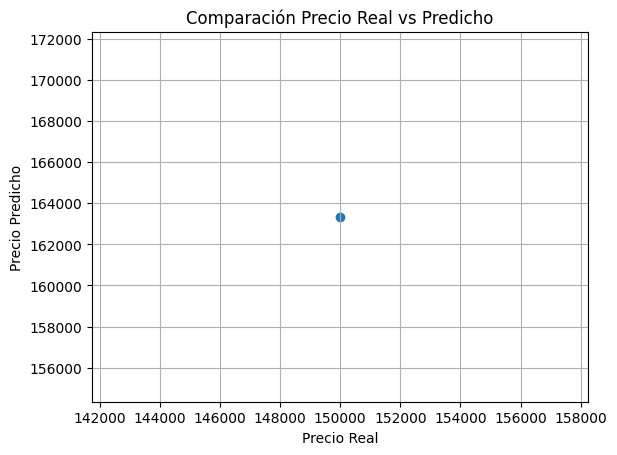

In [16]:
plt.scatter(y_test, y_pred)
plt.xlabel('Precio Real')
plt.ylabel('Precio Predicho')
plt.title('Comparación Precio Real vs Predicho')
plt.grid(True)
plt.show()